# 02-Activation function
> **Gole**: Why Do We Need Activation Functions?
Without them, stacking 100 layers = mathematically identical to 1 layer.
Activation functions add **non-linearity** so the network can learn complex patterns.
## Activation Functions Compared
| Function | Formula | Output | Use |
|----------|---------|--------|-----|
| ReLU | max(0,x) | 0 to inf | Hidden layers |
| Sigmoid | 1/(1+e^-x) | 0 to 1 | Binary output(y/n) |
| Softmax | e^x / sum(e^x) | probabilities | Multi-class, LLMs |



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Three activation functions ────────────────────────────

def relu(x):
    # if negative -> 0, if positive -> keep it
    # used in hidden layers: fast, no vanishing gradient
    return np.maximum(0, x)

def sigmoid(x):
    # squash any number into [0, 1]
    # used in output layer for binary (yes/no) problems
    return 1 / (1 + np.exp(-x))

def softmax(x):
    # convert scores to probabilities that sum to 1.0
    # used in LLMs to pick the next word
    e_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e_x / e_x.sum()

print('Activation functions defined successfully')

Activation functions defined successfully


In [ ]:
# ── Test with real numbers ────────────────────────────────

test_values = [-5, -2, -1, 0, 1, 2, 5]

print(f"{'x':>6} | {'relu(x)':>10} | {'sigmoid(x)':>12}")
print('-' * 36)
for v in test_values:
    print(f"{v:>6} | {relu(v):>10.4f} | {sigmoid(v):>12.4f}")

print('\nKey observations:')
print('  ReLU(-5) = 0     -> blocked')
print('  ReLU(5)  = 5     -> passed through unchanged')
print('  Sigmoid(-5) ~ 0  -> almost 0')
print('  Sigmoid(0)  = 0.5 -> exactly 50%')
print('  Sigmoid(5)  ~ 1  -> almost 1')
print('  Sigmoid(5)  ~ 1  -> almost 1')

     x |    relu(x) |   sigmoid(x)
------------------------------------
    -5 |     0.0000 |       0.0067
    -2 |     0.0000 |       0.1192
    -1 |     0.0000 |       0.2689
     0 |     0.0000 |       0.5000
     1 |     1.0000 |       0.7311
     2 |     2.0000 |       0.8808
     5 |     5.0000 |       0.9933

Key observations:
  ReLU(-5) = 0     -> blocked
  ReLU(5)  = 5     -> passed through unchanged
  Sigmoid(-5) ~ 0  -> almost 0
  Sigmoid(0)  = 0.5 -> exactly 50%
  Sigmoid(5)  ~ 1  -> almost 1
  Sigmoid(5)  ~ 1  -> almost 1


In [ ]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

raw_scores = np.array([1.2, 0.5, 3.1, -0.8, 2.0])
words = ['the', 'a', 'cat', 'jumped', 'dog']

probs = softmax(raw_scores)

print("Next word prediction after Softmax:\n")
for word, score, prob in zip(words, raw_scores, probs):
    print(f"{word}: score={score}, prob={prob:.1%}")

print(f"\nSum = {probs.sum():.4f} (always exactly 1.0)")
winner = words[np.argmax(probs)]
print(f'Chosen word: "{winner}" ({probs.max():.1%} probability)')

Next word prediction after Softmax:

the: score=1.2, prob=9.5%
a: score=0.5, prob=4.7%
cat: score=3.1, prob=63.4%
jumped: score=-0.8, prob=1.3%
dog: score=2.0, prob=21.1%

Sum = 1.0000 (always exactly 1.0)
Chosen word: "cat" (63.4% probability)


In [ ]:
# ── Softmax — critical for LLMs ──────────────────────────
# In GPT, the final layer outputs a score for every word in vocabulary
# Softmax converts these scores into probabilities

# Imagine GPT2 predicting next word after 'Deep learning is'
# These are raw scores (logits) for 5 candidate words
logits = np.array([2.1, 0.5, -1.2, 3.4, 0.8])
words  = ['a', 'the', 'not', 'very', 'quite']

probs = softmax(logits)

print("Predicting next word after 'Deep learning is...'")
print()
print(f"{'Word':<8} {'Raw Score':>10} {'Probability':>12} {'Bar'}")
print('-' * 50)
for w, s, p in sorted(zip(words, logits, probs), key=lambda x: -x[2]):
    bar = '█' * int(p * 30)
    print(f"'{w}'{'':.<6} {s:>10.1f} {p:>11.1%}  {bar}")

print(f'\nSum of all probabilities: {probs.sum():.4f} ← always 1.0')
print(f'Most likely next word: "{words[np.argmax(probs)]}"')

Predicting next word after 'Deep learning is...'

Word      Raw Score  Probability Bar
--------------------------------------------------
'very'......        3.4       70.8%  █████████████████████
'a'......        2.1       19.3%  █████
'quite'......        0.8        5.3%  █
'the'......        0.5        3.9%  █
'not'......       -1.2        0.7%  

Sum of all probabilities: 1.0000 ← always 1.0
Most likely next word: "very"


In [ ]:
for i in range(len(words)):
    print(words[i], probs[i])

a 0.19302753109451493
the 0.03897158640508763
not 0.0071194667424070565
very 0.7082752766038736
quite 0.052606139154116785


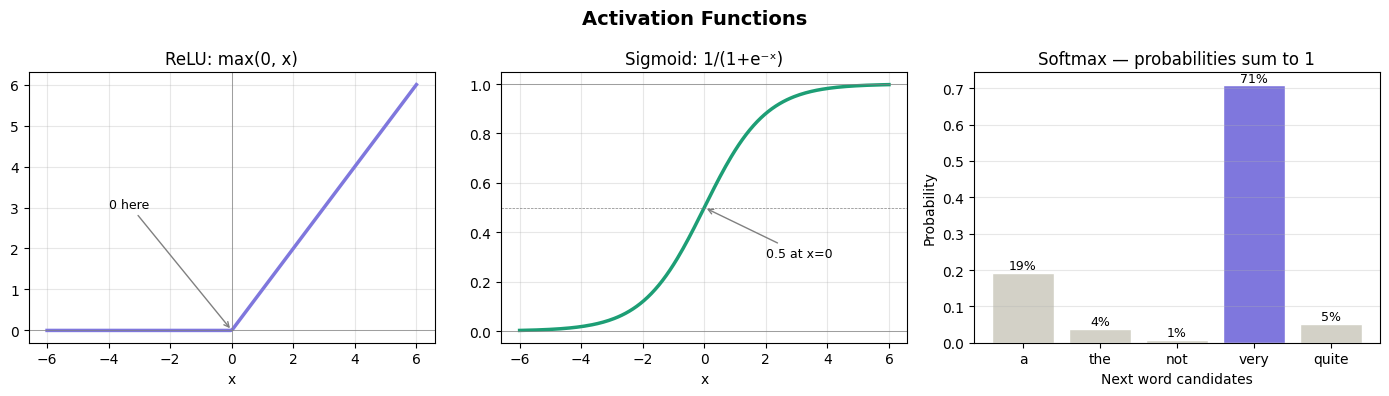

Plot saved as activation_functions.png


In [ ]:
# ── Visualize all three ───────────────────────────────────

x = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Activation Functions', fontsize=14, fontweight='bold')

# ReLU
axes[0].plot(x, relu(x), color='#7F77DD', linewidth=2.5)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('ReLU: max(0, x)')
axes[0].set_xlabel('x')
axes[0].annotate('0 here', xy=(0,0), xytext=(-4, 3), fontsize=9,
                  arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].grid(True, alpha=0.3)

# Sigmoid
axes[1].plot(x, sigmoid(x), color='#1D9E75', linewidth=2.5)
axes[1].axhline(0.5, color='gray', linewidth=0.5, linestyle='--')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axhline(1, color='gray', linewidth=0.5)
axes[1].set_title('Sigmoid: 1/(1+e⁻ˣ)')
axes[1].set_xlabel('x')
axes[1].annotate('0.5 at x=0', xy=(0, 0.5), xytext=(2, 0.3), fontsize=9,
                  arrowprops=dict(arrowstyle='->', color='gray'))
axes[1].grid(True, alpha=0.3)

# Softmax
words_plot  = ['a', 'the', 'not', 'very', 'quite']
logits_plot = [2.1, 0.5, -1.2, 3.4, 0.8]
probs_plot  = softmax(np.array(logits_plot))
colors = ['#7F77DD' if p == max(probs_plot) else '#D3D1C7' for p in probs_plot]
axes[2].bar(words_plot, probs_plot, color=colors, edgecolor='white')
axes[2].set_title('Softmax — probabilities sum to 1')
axes[2].set_ylabel('Probability')
axes[2].set_xlabel('Next word candidates')
for i, p in enumerate(probs_plot):
    axes[2].text(i, p + 0.01, f'{p:.0%}', ha='center', fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved as activation_functions.png')

In [ ]:
# ── Why ReLU beats Sigmoid for hidden layers ──────────────
# Sigmoid has the 'vanishing gradient' problem
# When x is very large or small, the gradient ≈ 0
# This means early layers learn almost nothing in deep networks

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu_derivative(x):
    return (x > 0).astype(float)

x_vals = np.array([-5, -3, -1, 0, 1, 3, 5])

print('Gradient comparison (backprop needs these):' )
print(f"{'x':>6} | {'sigmoid gradient':>18} | {'relu gradient':>15}")
print('-' * 48)
for v in x_vals:
    sg = sigmoid_derivative(v)
    rg = relu_derivative(v)
    flag = ' ← VANISHED!' if sg < 0.01 else ''
    print(f"{v:>6} | {sg:>18.6f} | {rg:>15.1f}{flag}")

print()
print('Problem: sigmoid gradient at x=5 is 0.006 — nearly zero!')
print('ReLU gradient is always 0 or 1 — no vanishing!')
print('This is why ReLU is default for hidden layers.')

Gradient comparison (backprop needs these):
     x |   sigmoid gradient |   relu gradient
------------------------------------------------
    -5 |           0.006648 |             0.0 ← VANISHED!
    -3 |           0.045177 |             0.0
    -1 |           0.196612 |             0.0
     0 |           0.250000 |             0.0
     1 |           0.196612 |             1.0
     3 |           0.045177 |             1.0
     5 |           0.006648 |             1.0 ← VANISHED!

Problem: sigmoid gradient at x=5 is 0.006 — nearly zero!
ReLU gradient is always 0 or 1 — no vanishing!
This is why ReLU is default for hidden layers.


**Key insight:** Softmax is what GPT uses to predict the next word.
After the last transformer layer, it outputs a score for every word in the vocabulary,
then softmax converts those scores into probabilities. The word with highest probability is chosen.